In [1]:
# TOOL to be used by the LLM

from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Use this to multiply two integers a and b
    a : int
    b : int
    """

    ans = a * b
    return int(ans)


In [5]:
# LLM

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

messages = [
    HumanMessage(content="What is 2 multiplied by 3")
]

llm = ChatGroq(model = "qwen/qwen3-32b", max_retries= 2, temperature= 0.7)
llm_with_tools = llm.bind_tools([multiply])

llm_with_tools.invoke(messages)

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 2 multiplied by 3". Let me see. I need to figure out if I should use the multiply function provided. The function takes two integers, a and b. The user is clearly asking for a multiplication of 2 and 3. So the parameters would be a=2 and b=3. I should call the multiply function with these values. Let me make sure there\'s no trick here. Both numbers are integers, so it fits the function\'s requirements. Yep, straightforward. Time to generate the tool call.\n', 'tool_calls': [{'id': 'tmve7fzb3', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 145, 'prompt_tokens': 176, 'total_tokens': 321, 'completion_time': 0.242577427, 'completion_tokens_details': {'reasoning_tokens': 116}, 'prompt_time': 0.008197278, 'prompt_tokens_details': None, 'queue_time': 0.052868306, 'total_time': 0.250774705}, 'model_nam

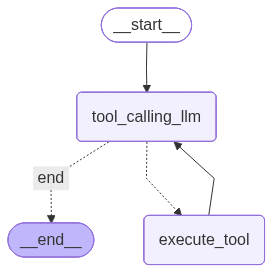

In [31]:
# Creating the graph
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage, ToolMessage
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState
from IPython.display import Image, display
import json

# state
class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# node 1: LLM with tools
def tool_calling_llm(state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# node 2: Execute the tool
def execute_tool(state):
    last_message = state["messages"][-1]
    tool_calls = last_message.tool_calls
    
    results = []
    for tool_call in tool_calls:
        if tool_call["name"] == "multiply":
            result = multiply.invoke({"a": int(tool_call["args"]["a"]), "b": int(tool_call["args"]["b"])})
            results.append(ToolMessage(content=str(result), tool_call_id=tool_call["id"]))
    
    return {"messages": results}

# conditional edge: Check if tool was called
def should_continue(state):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "execute_tool"
    else:
        return "end"

from langgraph.graph import StateGraph
from langgraph.graph import START, END

builder = StateGraph(MessageState)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("execute_tool", execute_tool)

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    should_continue,
    {
        "execute_tool": "execute_tool",
        "end": END
    }
)
builder.add_edge("execute_tool", "tool_calling_llm")  # Loop back

message_state_graph = builder.compile()

display(Image(message_state_graph.get_graph().draw_mermaid_png()))

In [37]:
from langchain_core.messages import HumanMessage
from pprint import pprint
for chunk in message_state_graph.stream({"messages": ["What is 4 multiplied by the 6"]}):
    pprint(chunk)

{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 4 multiplied by the 6". Let me see. First, I need to recognize that "multiplied by" indicates a multiplication operation. The numbers involved are 4 and 6. The function provided is called \'multiply\' and it takes two integers as parameters. So, I should use that function here. Let me check the parameters again to make sure. The function requires \'a\' and \'b\', both integers. So, plugging in 4 and 6. The user might have a typo with "the 6", but that\'s probably just emphasizing the number. So, the correct call would be multiply(4, 6). I need to make sure there\'s no other interpretation. Since there\'s no ambiguity, I can proceed with the function call.\n', 'tool_calls': [{'id': '802163jm6', 'function': {'arguments': '{"a":4,"b":6}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 196, 'prompt_tokens': 

{'messages': [HumanMessage(content='What is 4 multiplied by the 6', additional_kwargs={}, response_metadata={}, id='eab56dbf-75b5-4a65-a3aa-34f7bfc05dbd'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 4 multiplied by the 6". Let me see. They want to multiply 4 and 6. I need to use the multiply function provided. The function requires two integers, a and b. So, a is 4 and b is 6. I\'ll call the function with those parameters. The result should be 24. Let me make sure the parameters are correct. Yep, both are integers. Alright, time to format the tool call.\n', 'tool_calls': [{'id': 'xnqkas46z', 'function': {'arguments': '{"a":4,"b":6}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 177, 'total_tokens': 309, 'completion_time': 0.229079171, 'completion_tokens_details': {'reasoning_tokens': 103}, 'prompt_time': 0.02961814, 'prompt_tokens_details': No